## Model Training and Performance Comparison

- We will compare the performance of three classification models — Multinomial Naive Bayes, Logistic Regression, and Linear SVM — using the same TF-IDF-based text classification pipeline. Their performance will be evaluated using relevant metrics to identify the most suitable model for the ticket classification task. Performance results and comparison screenshots are included in the screenshots/ .

In [43]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

import joblib

from sklearn.model_selection import GridSearchCV

In [44]:
# Load Clean Dataset

df = pd.read_csv("../data/tickets.csv")

df.head()

,ticket_id,ticket_description,category,priority,status
0,T001,I am unable to sign in even though my username...,Login Issue,Critical,Open
1,T002,The application crashes when I attempt to impo...,Application Error,Critical,Open
2,T003,I need an audit report showing recent changes ...,Report,Critical,Open
3,T004,Unable to update company billing information a...,Account Update,Critical,Open
4,T005,Dashboard takes over 30 seconds to load data,Performance,Medium,Closed


In [45]:
# Select Features and Target

X = df["ticket_description"]
y = df["category"]

print(f"Number of samples: {len(df)}")
print(f"Number of categories: {y.nunique()}")
print("\nCategories:")
print(y.unique())

Number of samples: 250
Number of categories: 5

Categories:
['Login Issue' 'Application Error' 'Report' 'Account Update' 'Performance']


In [46]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 200
Testing samples: 50


In [47]:
# Check target distribution in Training set (%)
print("Training proportions:")
print(y_train.value_counts(normalize=True))

# Check target distribution in Testing set (%)
print("\nTesting proportions:")
print(y_test.value_counts(normalize=True))

Training proportions:
category
Application Error    0.2
Account Update       0.2
Login Issue          0.2
Report               0.2
Performance          0.2
Name: proportion, dtype: float64

Testing proportions:
category
Performance          0.2
Account Update       0.2
Application Error    0.2
Report               0.2
Login Issue          0.2
Name: proportion, dtype: float64


### Model trainnig

In [48]:
# Naive Bayes

# 1. Define base pipeline
model_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,                  # Step 1: Lowercases text
        token_pattern=r"(?u)\b[a-zA-Z]+\b", # Step 2: Keeps letters only (drops numbers & symbols)
        stop_words="english"             # Step 3: Removes English stop words
    )),
    ("classifier", MultinomialNB())
])

# 2. Hyperparameter Grid targeting overfitting
param_grid = {
    # --- TF-IDF Constraints (Reduce feature space noise) ---
    "tfidf__max_df": [0.75, 0.85, 0.90],       # Ignore words appearing in > X% of docs (removes corpus-specific stop words)
    "tfidf__min_df": [2, 3, 5],               # Ignore rare words appearing in < X docs (removes noise/typos)
    "tfidf__max_features": [1000, 2000, 5000],  # Hard cap on the vocabulary size
    "tfidf__ngram_range": [(1, 1), (1, 2)],     # Unigrams or Unigrams + Bigrams
    "tfidf__sublinear_tf": [True, False],       # Scales TF as 1 + log(tf) to damp high-frequency term impact

    # --- MultinomialNB Regularization ---
    "classifier__alpha": [0.1, 0.5, 1.0, 2.0, 5.0]  # Higher alpha = smoother probabilities = less overfitting
}

# 3. Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross-validation
    scoring="f1_macro",   # Or 'accuracy' / 'f1_weighted'
    n_jobs=-1,
    verbose=1
)

# 4. Fit on training data
grid_search.fit(X_train, y_train)

# Best Model
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Hyperparameters: {'classifier__alpha': 5.0, 'tfidf__max_df': 0.75, 'tfidf__max_features': 1000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}


In [49]:
# # Logistic Regression

# # 1. Define base pipeline
# model_pipeline = Pipeline([
#     ("tfidf", TfidfVectorizer(
#         lowercase=True,                  # Step 1: Lowercases text
#         token_pattern=r"(?u)\b[a-zA-Z]+\b", # Step 2: Keeps letters only (drops numbers & symbols)
#         stop_words="english"             # Step 3: Removes English stop words
#     )),
#     ("classifier", LogisticRegression(
#             max_iter=1000
#     ))
# ])


# # 2. Hyperparameter Grid
# param_grid = {

#     # --- TF-IDF Parameters ---
#     "tfidf__max_df": [0.75, 0.85, 0.90],
#     "tfidf__min_df": [2, 3, 5],
#     "tfidf__max_features": [1000, 2000, 5000],
#     "tfidf__ngram_range": [(1, 1), (1, 2)],
#     "tfidf__sublinear_tf": [True, False],

#     # --- Logistic Regression Parameters ---
#     "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
#     "classifier__solver": ["liblinear", "lbfgs"],
#     "classifier__class_weight": [None, "balanced"]
# }


# # 3. Perform Grid Search with Cross-Validation
# grid_search = GridSearchCV(
#     estimator=model_pipeline,
#     param_grid=param_grid,
#     cv=5,
#     scoring="f1_macro",
#     n_jobs=-1,
#     verbose=1
# )


# # 4. Fit on training data
# grid_search.fit(X_train, y_train)


# # Best Model
# best_model = grid_search.best_estimator_

# print("Best Hyperparameters:")
# print(grid_search.best_params_)

In [50]:
# # Linear SVM

# # 1. Define base pipeline
# model_pipeline = Pipeline([
#     ("tfidf", TfidfVectorizer(
#         lowercase=True,                  # Step 1: Lowercases text
#         token_pattern=r"(?u)\b[a-zA-Z]+\b", # Step 2: Keeps letters only (drops numbers & symbols)
#         stop_words="english"             # Step 3: Removes English stop words
#     )),
#     ("classifier", LinearSVC())
# ])



# # 2. Hyperparameter Grid
# param_grid = {

#     # --- TF-IDF Parameters ---
#     "tfidf__max_df": [0.75, 0.85, 0.90],
#     "tfidf__min_df": [2, 3, 5],
#     "tfidf__max_features": [1000, 2000, 5000],
#     "tfidf__ngram_range": [(1, 1), (1, 2)],
#     "tfidf__sublinear_tf": [True, False],

#     # --- Linear SVM Parameters ---
#     "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0]
# }


# # 3. Perform Grid Search with Cross-Validation
# grid_search = GridSearchCV(
#     estimator=model_pipeline,
#     param_grid=param_grid,
#     cv=5,
#     scoring="f1_macro",
#     n_jobs=-1,
#     verbose=1
# )


# # 4. Fit on training data
# grid_search.fit(X_train, y_train)


# # Best Model
# best_model = grid_search.best_estimator_

# print("Best Hyperparameters:")
# print(grid_search.best_params_)

In [51]:
# Accuracy Comparison

train_accuracy = best_model.score(X_train, y_train)
test_accuracy = best_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9950
Test Accuracy: 0.9800


In [52]:
# Evaluate the Model

y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9800


In [53]:
# Classification Report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                   precision    recall  f1-score   support

   Account Update       1.00      1.00      1.00        10
Application Error       1.00      1.00      1.00        10
      Login Issue       1.00      1.00      1.00        10
      Performance       1.00      0.90      0.95        10
           Report       0.91      1.00      0.95        10

         accuracy                           0.98        50
        macro avg       0.98      0.98      0.98        50
     weighted avg       0.98      0.98      0.98        50



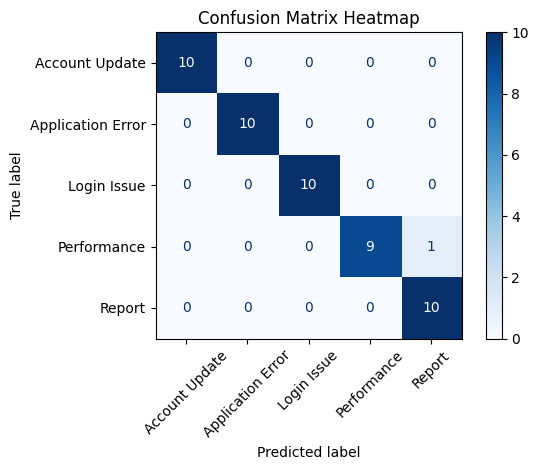

In [54]:
# Display directly from predictions

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    cmap="Blues", 
    xticks_rotation=45  # Rotates labels if you have long category names
)

plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()

In [55]:
# View Actual vs Predicted

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,Performance,Performance
1,Account Update,Account Update
2,Application Error,Application Error
3,Application Error,Application Error
4,Account Update,Account Update
5,Report,Report
6,Performance,Performance
7,Application Error,Application Error
8,Performance,Performance
9,Application Error,Application Error


In [56]:
# save model

# multinomial_nb_model.pkl/logistic_regression_model.pkl/linear_svm_model.pkl
joblib.dump(
    best_model,
    "../model/multinomial_nb_model.pkl" 
)

print("Complete model pipeline saved successfully.")

Complete model pipeline saved successfully.
